# Read Data Folder csv files and clean

In [17]:
from pathlib import Path
import pandas as pd

data_dir = Path("../Data")
structure_rows = []

for file in sorted([*data_dir.glob("*.csv"), *data_dir.glob("*.xlsx")]):
    if file.suffix == ".csv":
        temp = pd.read_csv(file)
    else:
        temp = pd.read_excel(file)
        temp.columns = temp.columns.str.strip()
        if "Date" not in temp.columns:
            temp = pd.read_excel(file, skiprows=6)

    temp.columns = temp.columns.str.strip()
    dates = pd.to_datetime(temp["Date"], errors="coerce").dropna().sort_values().reset_index(drop=True)
    gaps = dates.diff().dt.days.dropna()
    daily_run = (gaps <= 4).rolling(20, min_periods=20).mean()
    daily_start = daily_run[daily_run >= 0.8].index.min()

    structure_rows.append({
        "file": file.name,
        "rows": len(dates),
        "start": dates.min(),
        "end": dates.max(),
        "duplicates": dates.duplicated().sum(),
        "median_gap_days": gaps.median(),
        "max_gap_days": gaps.max(),
        "gaps_over_10d": (gaps > 10).sum(),
        "likely_daily_from": dates.iloc[daily_start] if pd.notna(daily_start) else pd.NaT,
    })

structure = pd.DataFrame(structure_rows)
structure


,file,rows,start,end,duplicates,median_gap_days,max_gap_days,gaps_over_10d,likely_daily_from
0,1.cleaned_return_df.csv,10924,1991-12-31,2021-11-26,0,1.0,1.0,0,1992-01-20
1,Bloomberg Barclays EM AGG.xlsx,6280,1993-01-29,2021-11-24,0,1.0,33.0,47,1997-01-24
2,Bloomberg Barclays Global AGG.xlsx,6017,1991-12-31,2021-11-24,0,1.0,33.0,84,1999-01-26
3,Bloomberg Barclays US 1-3 month treasury.xlsx,6116,1991-12-31,2021-11-24,0,1.0,33.0,69,1997-10-23
4,Bloomberg Barclays US ABS.xlsx,6959,1991-12-31,2021-11-24,0,1.0,33.0,26,1994-03-22
5,Bloomberg Barclays US AGG.xlsx,7482,1991-12-31,2021-11-24,0,1.0,5.0,0,1992-01-30
6,Bloomberg Barclays US Corp HY.xlsx,5910,1991-12-31,2021-11-24,0,1.0,33.0,80,1998-08-31
7,Bloomberg Barclays US Corp IG.xlsx,7482,1991-12-31,2021-11-24,0,1.0,4.0,0,1992-01-30
8,Bloomberg Barclays US Inflation Protected 7-10...,6454,1997-02-28,2021-11-24,0,1.0,3.0,0,1997-03-28
9,Bloomberg Barclays US Inflation Protected.xlsx,5928,1997-03-31,2021-11-24,0,1.0,33.0,13,1998-05-07


In [18]:
from pathlib import Path
import pandas as pd

data_dir = Path("../Data")

historical = pd.read_csv(data_dir / "historical_asset_return_daily.csv")
historical.columns = historical.columns.str.strip()
historical["Date"] = pd.to_datetime(historical["Date"])
historical = historical.set_index("Date")

price_dfs = []

for file in data_dir.glob("*.xlsx"):
    temp = pd.read_excel(file)
    temp.columns = temp.columns.str.strip()
    if "Date" not in temp.columns:
        temp = pd.read_excel(file, skiprows=6)
        temp.columns = temp.columns.str.strip()
    temp["Date"] = pd.to_datetime(temp["Date"])
    temp = temp.set_index("Date")
    if "PX_LAST" in temp.columns:
        price_dfs.append(temp[["PX_LAST"]].rename(columns={"PX_LAST": file.stem}))

prices = pd.concat(price_dfs, axis=1, sort=True).sort_index()
prices = prices.reindex(historical.index).ffill()
price_returns = prices.pct_change()
return_df = historical.join(price_returns)


### Used historical file as datetime convention.
historical shape: (10924, 4)
prices shape after reindex: (10924, 26)
return_df shape: (10924, 30)
return_df.index equals historical.index: True

In [19]:

return_df.head()

,dm_stock,em_stock,fixed_income,commodity,Bloomberg Barclays EM AGG,Bloomberg Barclays Global AGG,Bloomberg Barclays US 1-3 month treasury,Bloomberg Barclays US ABS,Bloomberg Barclays US AGG,Bloomberg Barclays US Corp HY,...,MSCI World Real Estate,MSCI World Value,MSCI World x US,MSCI World,MSCI_All Country World,Russel 300 TR,SNP global infrastructure,SNP GSCI TR,SNP metal and mining,SNP oil gas exploration and production
Date,,,,,,,,,,,,,,,,,,,,,
1991-12-31,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-01,0.000000,0.000000,0.0,0.000000,NaN,0.0,0.0,0.0,0.000000,0.0,...,NaN,0.0,0.0,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN
1992-01-02,0.000897,0.014370,0.0,0.005368,NaN,0.0,0.0,0.0,-0.002171,0.0,...,NaN,0.0,0.0,0.000897,0.001356,-0.000451,NaN,0.005368,NaN,NaN
1992-01-03,0.000746,0.013859,0.0,-0.004197,NaN,0.0,0.0,0.0,-0.001497,0.0,...,NaN,0.0,0.0,0.000746,0.001128,0.005236,NaN,-0.004197,NaN,NaN
1992-01-04,0.000000,0.000000,0.0,0.000000,NaN,0.0,0.0,0.0,0.000000,0.0,...,NaN,0.0,0.0,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN


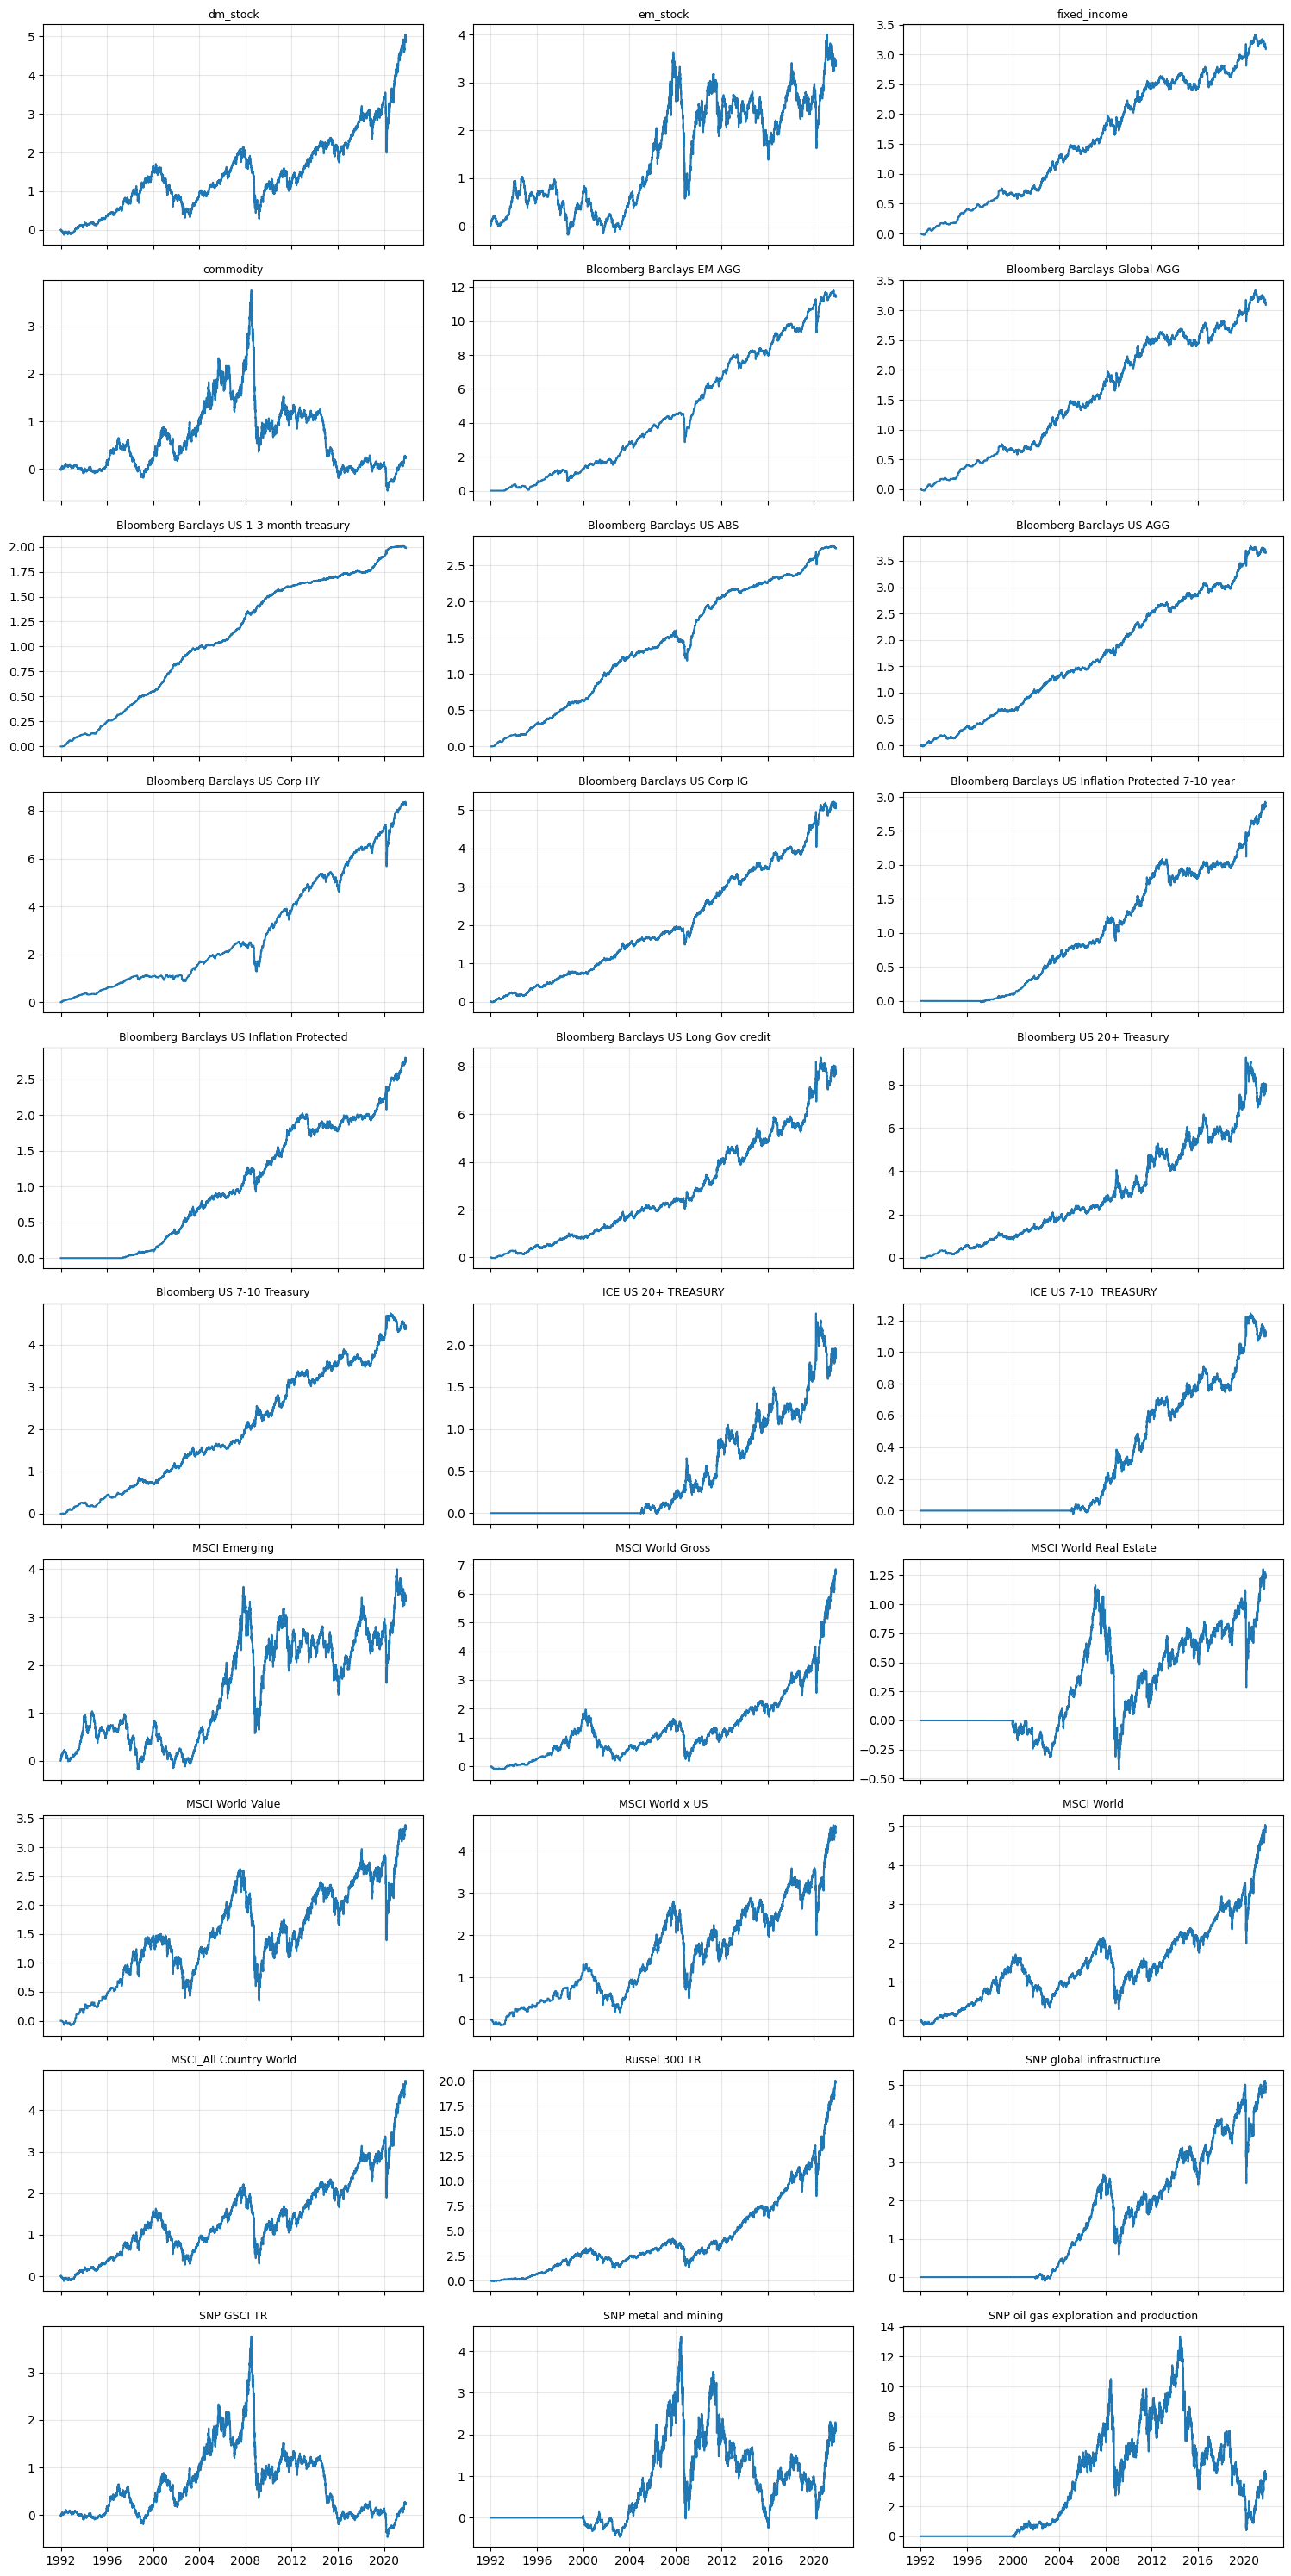

In [22]:
import matplotlib.pyplot as plt

cum_return = (1 + return_df.fillna(0)).cumprod() - 1

n_cols = 3
n_rows = -(-len(cum_return.columns) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(cum_return.columns):
    axes[i].plot(cum_return.index, cum_return[col])
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)

for ax in axes[len(cum_return.columns):]:
    ax.remove()

plt.tight_layout()
plt.savefig("../Data/1.cumulative_return_charts.png", dpi=300, bbox_inches="tight")
plt.show()

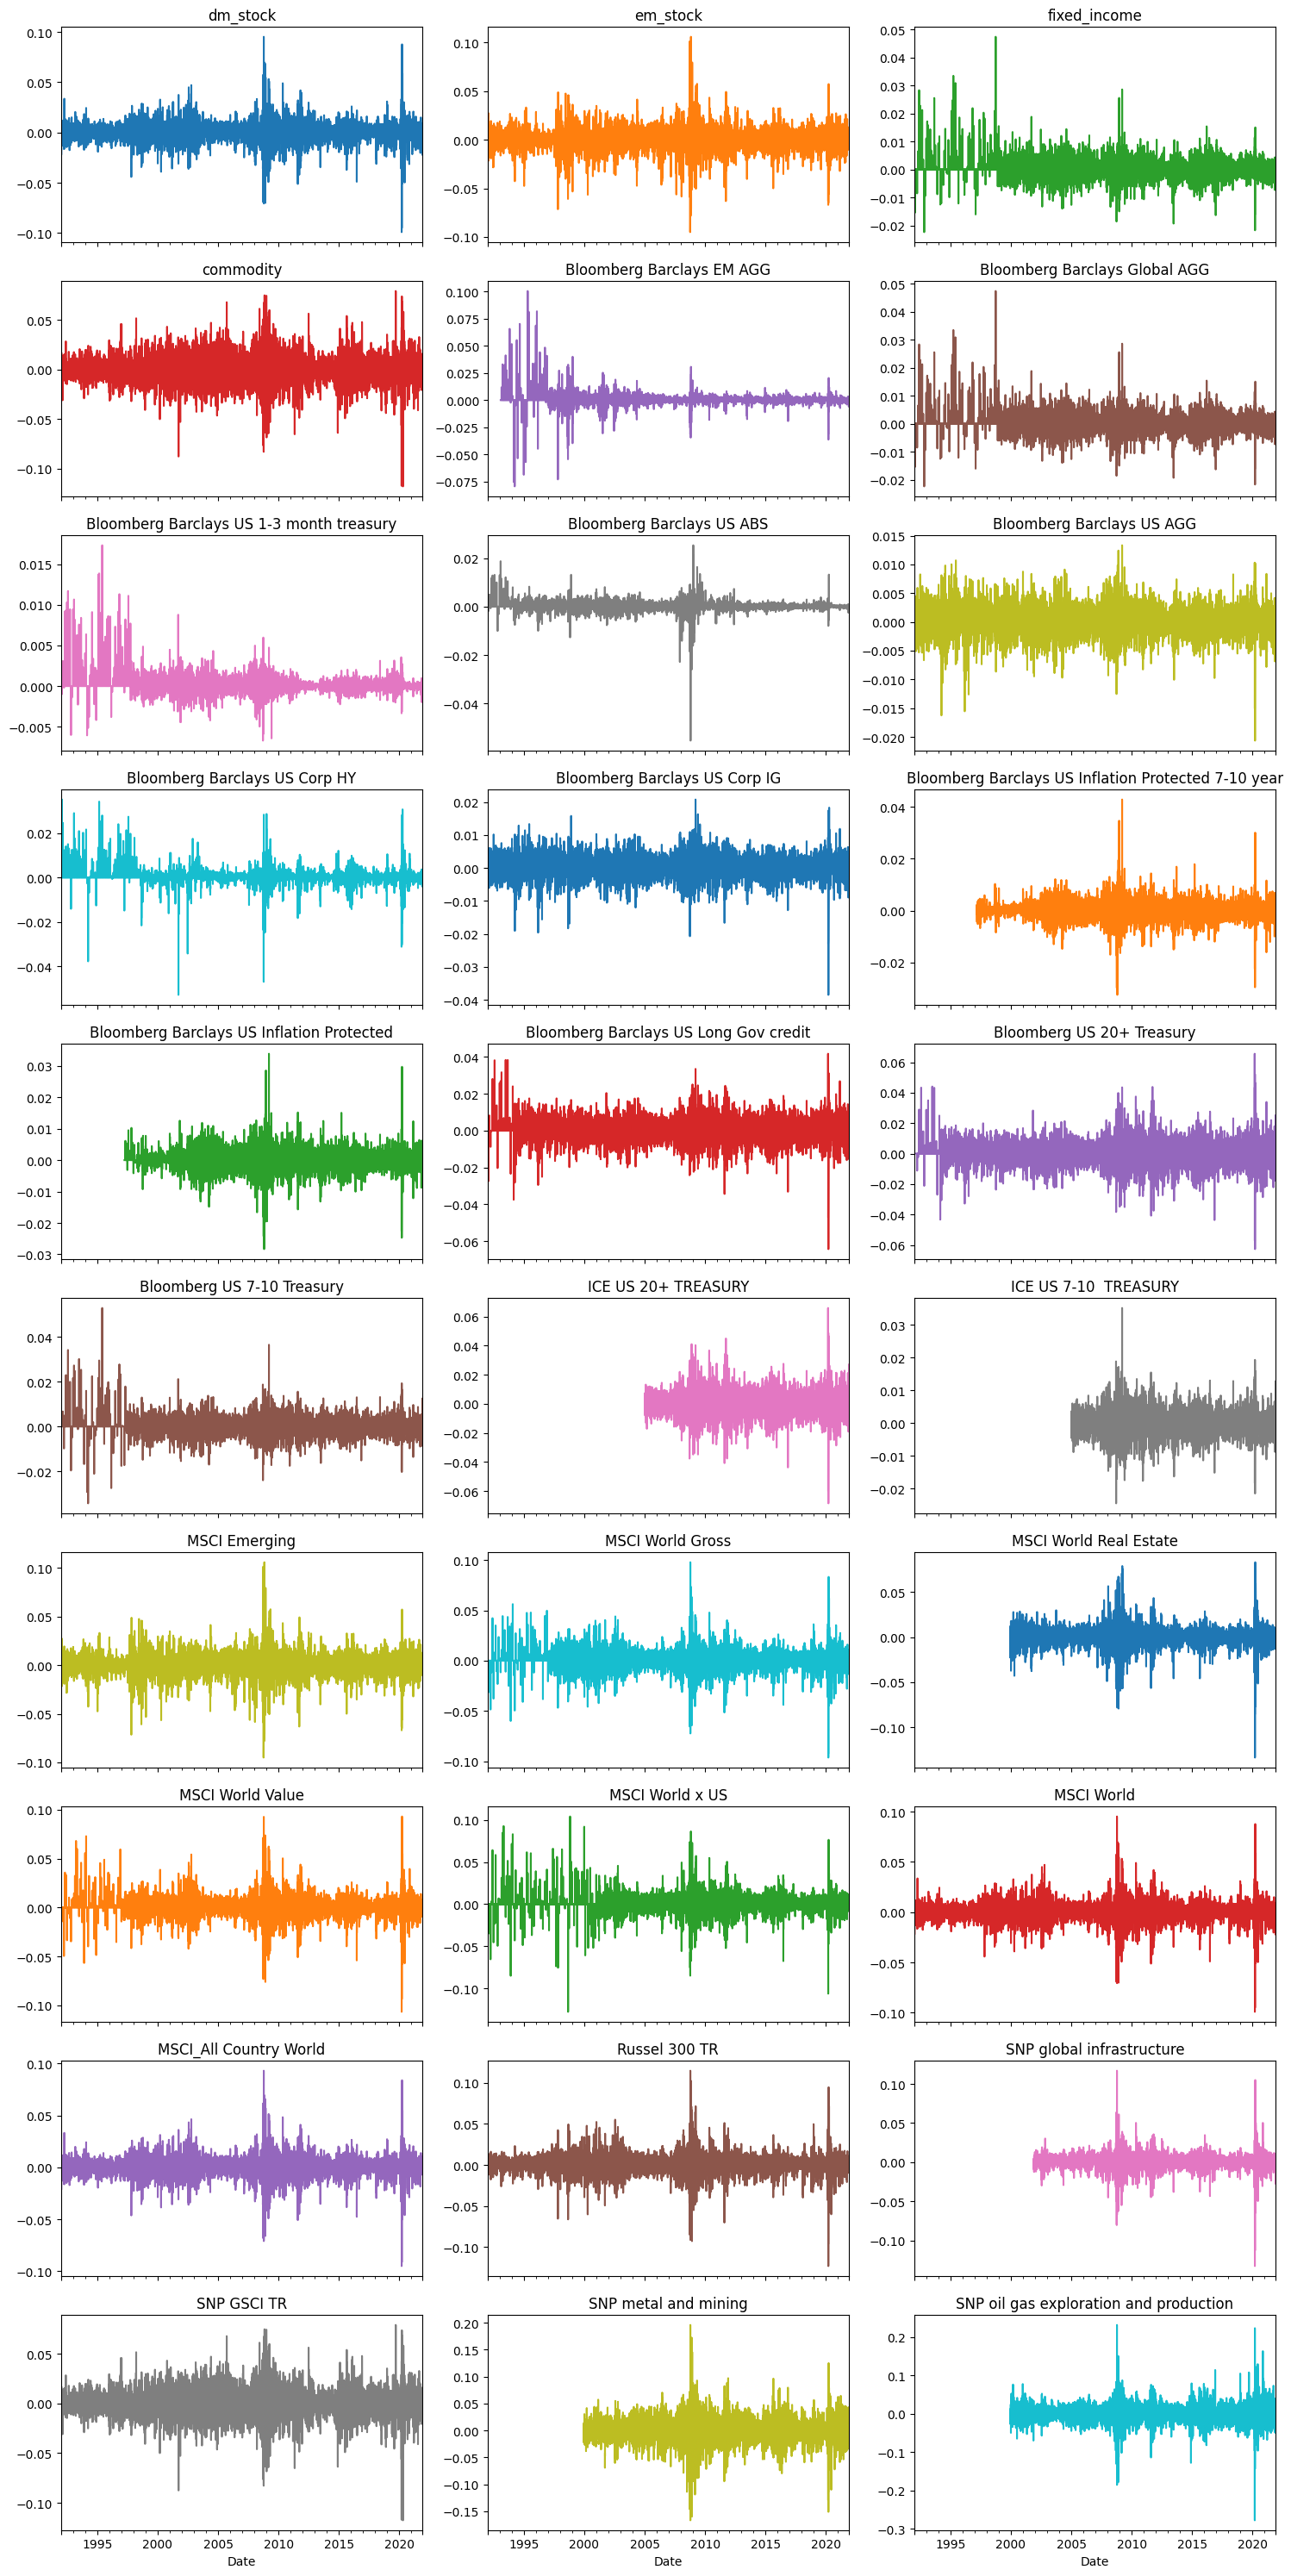

In [21]:
return_df.plot(
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 30),
    sharex=True,
    legend=False,
    title=return_df.columns.tolist()
)

plt.tight_layout()
plt.show()

In [ ]:
# Download Returns DF
return_df.to_csv("../Data/1.cleaned_return_df.csv", index=True)

## Data Cleaning Summary

`return_df` is the final cleaned return dataset.

- `historical_asset_return_daily.csv` is the base calendar and already contains returns.
- Excel files use `PX_LAST` as price/index levels; `CHG_PCT_1D` is ignored.
- Files with description rows are handled using `skiprows=6` when `Date` is not found.
- Excel prices are reindexed to `historical.index`, forward-filled, then converted to returns with `.pct_change()`.
- Final output is saved to `../Data/1.cleaned_return_df.csv`.

Note: some series start monthly before becoming daily, so consider inspecting missingness or starting ML around `2001-01-22`.